In [1]:
# %reload_ext autoreload
# %autoreload 2

# import py4DSTEM
# import numpy as np
# import matplotlib.pyplot as plt
# import h5py
# from microstructure_inference.dataProcessing import read_4D, align, make_orientation_map_based_on_4D_rotation_matrices
# from scipy.signal import correlate as Scipycor
# import skimage
# from microstructure_inference.analysis.measure_correlation_score import measure_sparseCorr_of_single_pattern, orientation_plan_init_for_single_pattern, Q_calculation
# from skimage.metrics import hausdorff_distance, structural_similarity, mean_squared_error
# import pandas as pd
# from py4DSTEM import show
# from scipy import ndimage
# import torch
# # from chamferdist import ChamferDistance
# from py4DSTEM.data import QPoints
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import gaussian_kde
# from matplotlib.ticker import ScalarFormatter
# from py4DSTEM.preprocess.utils import get_maxima_2D
# print(py4DSTEM.__version__)
# %autoreload 2

0.14.8


In [1]:
%reload_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import py4DSTEM
from scipy.stats import ks_2samp
from matplotlib.ticker import ScalarFormatter
from scipy.stats import gaussian_kde
import numpy as np
import pickle
from matplotlib.colors import ListedColormap
from microstructure_inference.dataProcessing import read_4D, align, make_orientation_map_based_on_4D_rotation_matrices
import torch
import os
from microstructure_inference.analysis.measure_correlation_score import radial_average_corrMap, zone_axis_cross_correlation_map_masked, zone_axis_autocorrelation_map_masked, zone_axis_local_correlation_map

print(py4DSTEM.__version__)
%autoreload 2

0.14.8


In [2]:
trained_model_indicator_index = "sing_05"
correlationThresholdTemplateMatch = int(14000)

In [3]:

pixel_size = 0.0328
# pixel_size = 0.03158073
sigma_compare = 0.02
pixel_numbers = 128

k_max = pixel_size * pixel_numbers / 2.
accelerating_voltage = int(300e3)


script_path = os.getcwd() + "/"
processed_data_saving_path = script_path + "processed_data/"
fig05_panel_a_c_path = script_path + "figure_05_panel_a_c/"
fig05_panel_d_f_path = script_path + "figure_05_panel_d_f/"
file_path = script_path + "../"



In [4]:




raw_data_path = "/home/kwang/Desktop/Storage/project/p03_orientation_mapping/figure/experimental_raw_data/"


raw_file = raw_data_path + 'scan_x256_y256.raw'

# bragg_peak_calibrated_name = "./" + "m2_bragg_disks_corThForK80000_dog_sig1_2.00_sig2_8.00_cortThForTemp_20000.h5"

data = read_4D(raw_file)
nan_pos_data = np.isnan(data)
data[nan_pos_data] = 1
aligned_data = align(data)
aligned_data = aligned_data[0]
aligned_data = aligned_data[:,:150]
datacube_aligned_data = py4DSTEM.DataCube(aligned_data)

datacube_aligned_data.get_dp_max()
datacube_aligned_data.get_dp_mean()
dp_mean = datacube_aligned_data.get_dp_mean()
dp_max = datacube_aligned_data.get_dp_max()

 255,255          

In [5]:


filepath_analysis = "./"

Bragg_vector_file_name = "bragg_disks_corThForK80000_dog_sig1_2.00_sig2_6.00_cortThForTemp_%d"%(correlationThresholdTemplateMatch)
filepath_braggdisks_cal = file_path + Bragg_vector_file_name + ".h5"
bragg_peaks = py4DSTEM.read(filepath_braggdisks_cal)
file_str_after_preprocessing = trained_model_indicator_index + "_" + Bragg_vector_file_name
prediced_rotation_matrices = np.load(processed_data_saving_path + file_str_after_preprocessing + "_rotation_matrices_canonical.npy")


DP_2D_indices_in_scan_space = []
intensities = []

table_BPs_scanIndex = {}
dict_idx = 0
for i in range(bragg_peaks.shape[0]):
    for j in range(bragg_peaks.shape[1]):
        if len(bragg_peaks.cal[i,j].qx) > 2:

            qx = np.copy(bragg_peaks.cal[i,j].data["qx"])
            qy = np.copy(bragg_peaks.cal[i,j].data["qy"])
            intensity = np.copy(bragg_peaks.cal[i,j].data["intensity"] / np.max(bragg_peaks.cal[i,j].data["intensity"]))

            k_radial_distnaces_of_BPs = np.linalg.norm(np.stack((qx, qy)).T, axis = 1)
            index_of_direct_beam = np.argmin(k_radial_distnaces_of_BPs)

            qx = np.delete(qx, index_of_direct_beam)
            qy = np.delete(qy, index_of_direct_beam)
            intensity = np.delete(intensity, index_of_direct_beam)

            

            positions_of_Bragg_disks = np.stack((qx, qy)).T
            k_radial_distnaces_of_BPs = np.linalg.norm(positions_of_Bragg_disks, axis = 1)
            polar_angles = np.arctan2(positions_of_Bragg_disks[:,1], positions_of_Bragg_disks[:,0])


            table_BPs_scanIndex[dict_idx] = {'input': np.stack((k_radial_distnaces_of_BPs, polar_angles, intensity)).T, 'scanIndices': [i,j]}

            dict_idx += 1
            
torch_input = torch.load(processed_data_saving_path + file_str_after_preprocessing + "_table.pt")

Reading PointListArray: 100%|███| 38400/38400 [00:02<00:00, 16448.01PointList/s]


In [6]:

crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(file_path + "Cu_fcc.cif")
crystal.setup_diffraction(accelerating_voltage)
crystal.calculate_structure_factors(
    k_max,
)

# # Create an orientation plan for [0001] WS2
# crystal.orientation_plan(
#     angle_step_zone_axis = 1,
#     angle_step_in_plane = 1,
#     accel_voltage = 300e3,
#     corr_kernel_size= 0.08, # was 0.08 before 0.12 not bad
#     zone_axis_range='auto',
# )

# Create an orientation plan for [0001] WS2
crystal.orientation_plan(
    angle_step_zone_axis = 2,
    angle_step_in_plane = 2,
    accel_voltage = accelerating_voltage,
    # intensity_power = 0.5,
    # corr_kernel_size= 0.08, # was 0.08 before 0.12 not bad
    zone_axis_range='auto',
)


Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████| 406/406 [00:00<00:00, 4058.96 zone axes/s]


# Figure 5_Supplementary

In [7]:

py4DSTEM_predicted_rotation_matrices = np.load(processed_data_saving_path + trained_model_indicator_index + '_py4DSTEM_predicted_rotation_matrices_%d.npy'%(correlationThresholdTemplateMatch))

sparseCorrValue_from_py4DSTEM_prediction = np.load(processed_data_saving_path +  trained_model_indicator_index + '_sparseCorrValue_from_py4DSTEM_prediction_%d.npy'%(correlationThresholdTemplateMatch))
sparseCorrValue_from_transformer_prediction = np.load(processed_data_saving_path +  trained_model_indicator_index + '_sparseCorrValue_from_transformer_prediction_%d.npy'%(correlationThresholdTemplateMatch))

QCorrValue_from_py4DSTEM_prediction = np.load(processed_data_saving_path +  trained_model_indicator_index + '_QCorrValue_from_py4DSTEM_prediction_%d.npy'%(correlationThresholdTemplateMatch))
QCorrValue_from_transformer_prediction = np.load(processed_data_saving_path +  trained_model_indicator_index + '_QCorrValue_from_transformer_prediction_%d.npy'%(correlationThresholdTemplateMatch))


In [10]:
np.where(sparseCorrValue_from_transformer_prediction< 1e-12)[0]

array([  15,   19,   24, ..., 8872, 8884, 8886], shape=(1389,))

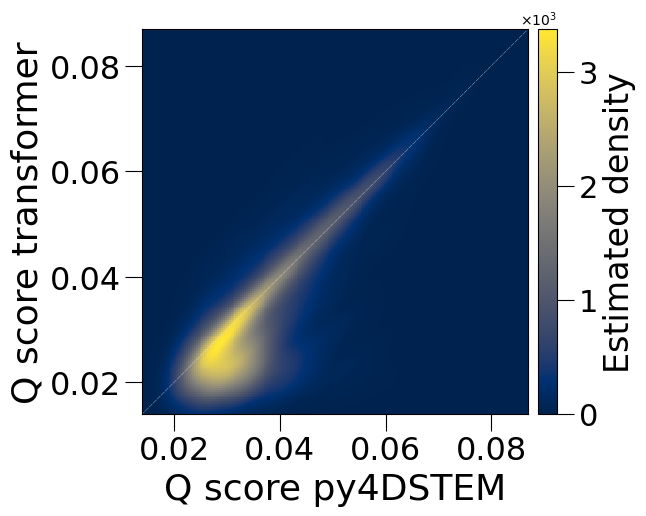

In [5]:

x = np.array(QCorrValue_from_py4DSTEM_prediction)
y = np.array(QCorrValue_from_transformer_prediction)

# ---------- KDE ----------
xy = np.vstack([x, y])
kde = gaussian_kde(xy)

# ---------- Axis limits ----------
xmin, xmax = 0.014, 0.087   # <-- set as needed
ymin, ymax = 0.014, 0.087


# ---------- Grid for KDE ----------
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(6, 5))

pcm = ax.pcolormesh(
    xx, yy, zz,
    cmap="cividis",
    shading="auto",
    edgecolors="none",
    linewidth=0,
    rasterized=True
)

ax.plot(
    [xmin, xmax],   # x coordinates
    [xmin, xmax],   # y coordinates
    color="#FFFFFF",    # line color
    linestyle=(5, (17, 3)), # dashed line
    linewidth=0.2,    # line thickness
    label="y = x"   # optional legend
)

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))   # always use scientific notation

cbar = fig.colorbar(pcm, 
                    ax=ax, 
                    pad=0.02,
                    label="Estimated density")
cbar.set_label("Estimated density", fontsize=24)
cbar.ax.tick_params(
    length=12,      # tick length
    width=0.8,      # tick thickness
    labelsize=22    # tick label font size
)

cbar.formatter = formatter
cbar.update_ticks()

# ---------- Limits ----------
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# ---------- Ticks ----------
ax.set_xticks([0.02,0.04,0.06,0.08])  # 6 ticks
ax.set_yticks([0.02,0.04,0.06,0.08])

ax.tick_params(
    axis="both",
    which="major",
    length=12,
    width=0.8,
    labelsize=23
)

# ---------- Labels ----------
ax.set_xlabel("Q score py4DSTEM", fontsize=26)
ax.set_ylabel("Q score transformer", fontsize=26)
# ax.set_title("2D KDE Density Plot", fontsize=16)

# ax.grid(True)

fig.savefig(fig05_panel_a_c_path + trained_model_indicator_index + "_QCorrValue_density_plot_both_trans_and_py4DSTEM.pdf", bbox_inches='tight')
fig.savefig(fig05_panel_a_c_path + trained_model_indicator_index + "_QCorrValue_density_plot_both_trans_and_py4DSTEM.png", bbox_inches='tight')
plt.show()

In [9]:
QCorrValue_min_bound = min(np.min(QCorrValue_from_py4DSTEM_prediction), np.min(QCorrValue_from_transformer_prediction))

QCorrValue_max_bound = max(np.max(QCorrValue_from_py4DSTEM_prediction), np.max(QCorrValue_from_transformer_prediction))

print("QCorrValue_min_bound\n", QCorrValue_min_bound, "\n")
print("QCorrValue_max_bound\n", QCorrValue_max_bound)

QCorrValue_min_bound
 0.015257284602974345 

QCorrValue_max_bound
 0.0839043388778001


In [10]:

sparseCorrValue_min_bound = min(np.min(sparseCorrValue_from_py4DSTEM_prediction), np.min(sparseCorrValue_from_transformer_prediction))

sparseCorrValue_max_bound = max(np.max(sparseCorrValue_from_py4DSTEM_prediction), np.max(sparseCorrValue_from_transformer_prediction))

print("sparseCorrValue_min_bound\n", sparseCorrValue_min_bound, "\n")
print("sparseCorrValue_max_bound\n", sparseCorrValue_max_bound)

sparseCorrValue_min_bound
 0.0 

sparseCorrValue_max_bound
 2.1972570131845055


KS statistic: 0.2605467431657104
p-value: 1.5958973054242664e-265
pyxem cross correlation


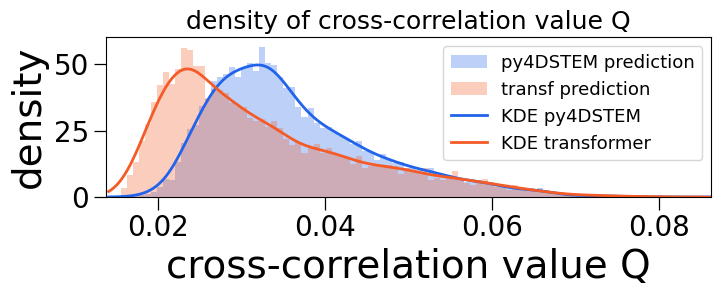

KS statistic: 0.5063561705478682
p-value: 0.0


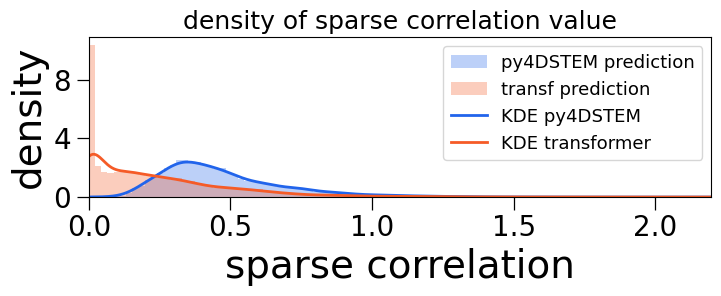

In [11]:
## from scipy.stats import gaussian_kde


n_bins = 100

Q_score_lower_bound = 0.0141
Q_score_upper_bound = 0.0862

sparse_score_lower_bound = 0.0
sparse_score_upper_bound = 2.198

kde_grid_num = 4000
pyxem_corr_x_grid = np.linspace(Q_score_lower_bound, Q_score_upper_bound, kde_grid_num) 

kde_pyxem_corr_py4DSTEM = gaussian_kde(QCorrValue_from_py4DSTEM_prediction)
kde_pyxem_corr_transfor = gaussian_kde(QCorrValue_from_transformer_prediction)

bandwidth_pyxem_corr_py4DSTEM = kde_pyxem_corr_py4DSTEM.factor * QCorrValue_from_py4DSTEM_prediction.std(ddof=1)
bandwidth_pyxem_corr_transfor = kde_pyxem_corr_transfor.factor * QCorrValue_from_transformer_prediction.std(ddof=1)

pdf_est_pyxem_corr_py4DSTEM = kde_pyxem_corr_py4DSTEM(pyxem_corr_x_grid)
pdf_est_pyxem_corr_transfor = kde_pyxem_corr_transfor(pyxem_corr_x_grid)


D_stat, p_value = ks_2samp(QCorrValue_from_py4DSTEM_prediction,
                           QCorrValue_from_transformer_prediction)

print("KS statistic:", D_stat)
print("p-value:", p_value)


print("pyxem cross correlation")
fig, axs = plt.subplots(1, 1, figsize=(7.5, 3), tight_layout=True)
# We can set the number of bins with the *bins* keyword argument.
axs.set_title("density of cross-correlation value Q", fontsize = 18)
axs.hist(QCorrValue_from_py4DSTEM_prediction, range = (Q_score_lower_bound, Q_score_upper_bound), density = True, bins=n_bins, alpha = 0.3, color = '#2164EB', label='py4DSTEM prediction')
axs.hist(QCorrValue_from_transformer_prediction, range = (Q_score_lower_bound, Q_score_upper_bound), density = True, bins=n_bins, alpha = 0.3, color = '#F55B27', label='transf prediction')
axs.plot(pyxem_corr_x_grid, pdf_est_pyxem_corr_py4DSTEM, label='KDE py4DSTEM', linewidth=2, color = "#2164EB")
axs.plot(pyxem_corr_x_grid, pdf_est_pyxem_corr_transfor, label='KDE transformer', linewidth=2, color = "#F55B27")
axs.set_position([0.1, 0.15, 0.77, 0.75])  # [left, bottom, width, height] in relative figure coordinates
axs.set_xlim([0.0138,Q_score_upper_bound])
axs.set_ylim([-0.01,60])
axs.legend(fontsize = 13)
axs.set_yticks([0, 25, 50])
axs.set_xlabel(r"cross-correlation value Q", fontsize = 28)
axs.set_ylabel(r"density", fontsize = 28)
plt.tick_params(axis = 'both', labelsize = 20, length = 9, width = 0.9, color ='k')
plt.tight_layout()
plt.savefig(fig05_panel_a_c_path + trained_model_indicator_index + "_Q_correlation_score_comparison.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()


py4DSTEM_corr_x_grid = np.linspace(sparse_score_lower_bound, sparse_score_upper_bound, kde_grid_num) 

kde_py4DSTEM_corr_py4DSTEM = gaussian_kde(sparseCorrValue_from_py4DSTEM_prediction)
kde_py4DSTEM_corr_transfor = gaussian_kde(sparseCorrValue_from_transformer_prediction)

pdf_est_py4DSTEM_corr_py4DSTEM = kde_py4DSTEM_corr_py4DSTEM(py4DSTEM_corr_x_grid)
pdf_est_py4DSTEM_corr_transfor = kde_py4DSTEM_corr_transfor(py4DSTEM_corr_x_grid)

D_stat, p_value = ks_2samp(sparseCorrValue_from_py4DSTEM_prediction,
                           sparseCorrValue_from_transformer_prediction)

print("KS statistic:", D_stat)
print("p-value:", p_value)


fig, axs = plt.subplots(1, 1, figsize=(7.5, 3), tight_layout=True)
# We can set the number of bins with the *bins* keyword argument.
axs.set_title("density of sparse correlation value", fontsize = 18)
axs.hist(sparseCorrValue_from_py4DSTEM_prediction, range = (sparse_score_lower_bound, sparse_score_upper_bound), bins=n_bins, density = True, alpha = 0.3, color = '#2164EB', label='py4DSTEM prediction')
axs.hist(sparseCorrValue_from_transformer_prediction, range = (sparse_score_lower_bound, sparse_score_upper_bound), bins=n_bins, density = True, alpha = 0.3, color = '#F55B27', label='transf prediction')
axs.plot(py4DSTEM_corr_x_grid, pdf_est_py4DSTEM_corr_py4DSTEM, label='KDE py4DSTEM', linewidth=2, color = "#2164EB")
axs.plot(py4DSTEM_corr_x_grid, pdf_est_py4DSTEM_corr_transfor, label='KDE transformer', linewidth=2, color = "#F55B27")
axs.set_position([0.1, 0.15, 0.77, 0.75])  # [left, bottom, width, height] in relative figure coordinates
axs.set_xlim([-0.001,sparse_score_upper_bound])


# axs.set_ylim([-0.01,1700])
axs.legend(fontsize = 13)
axs.set_yticks([0.0, 4, 8])
axs.set_xlabel(r"sparse correlation", fontsize = 28)
axs.set_ylabel(r"density", fontsize = 28)
# axs.axvline(x = dominant_angle, color = '#f009f0', linewidth = 3)
plt.tick_params(axis = 'both', labelsize = 20, length = 9, width = 0.9, color ='k')
plt.tight_layout()
plt.savefig(fig05_panel_a_c_path + trained_model_indicator_index + "_sparse_correlation_score_comparison.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()

In [12]:
# Set seed
np.random.seed(14)  # any integer works

indices_of_keys_where_py4DSTEM_is_clearly_better_than_model = np.where(QCorrValue_from_py4DSTEM_prediction > QCorrValue_from_transformer_prediction * 1.5)[0]

# Multiple random integers
randomly_drawn_indices = np.random.randint(0, len(indices_of_keys_where_py4DSTEM_is_clearly_better_than_model), size=6)

keys_where_py4DSTEM_is_clearly_better_than_model = indices_of_keys_where_py4DSTEM_is_clearly_better_than_model[randomly_drawn_indices]


print("RANDOMLY DRAWN KEY WHERE PY4DSTEM-matching is clearly better than model prediction:\n\n", keys_where_py4DSTEM_is_clearly_better_than_model, "\n")

for key in keys_where_py4DSTEM_is_clearly_better_than_model:
    print("")
    print("py4DSTEM Q score:", QCorrValue_from_py4DSTEM_prediction[key])
    print("transformer Q score:", QCorrValue_from_transformer_prediction[key])

RANDOMLY DRAWN KEY WHERE PY4DSTEM-matching is clearly better than model prediction:

 [5114 3313 2789 6242 5545 4546] 


py4DSTEM Q score: 0.0569442956083482
transformer Q score: 0.02518105041820835

py4DSTEM Q score: 0.03253281876480316
transformer Q score: 0.018685140007616396

py4DSTEM Q score: 0.030434212986751082
transformer Q score: 0.019425070168004502

py4DSTEM Q score: 0.03400181686656442
transformer Q score: 0.0222743752479196

py4DSTEM Q score: 0.04101140314399768
transformer Q score: 0.022509629893475123

py4DSTEM Q score: 0.027495877377421953
transformer Q score: 0.017484104852922643


# two point correlation function

In [7]:
scan_x_dim = bragg_peaks.shape[0]
scan_y_dim = bragg_peaks.shape[1]

DP_2D_indices_in_scan_space = []
intensities = []

table_BPs_scanIndex = {}
dict_idx = 0
for i in range(scan_x_dim):
    for j in range(scan_y_dim):
        if len(bragg_peaks.cal[i,j].qx) > 2:

            qx = np.copy(bragg_peaks.cal[i,j].data["qx"])
            qy = np.copy(bragg_peaks.cal[i,j].data["qy"])
            intensity = np.copy(bragg_peaks.cal[i,j].data["intensity"] / np.max(bragg_peaks.cal[i,j].data["intensity"]))

            k_radial_distnaces_of_BPs = np.linalg.norm(np.stack((qx, qy)).T, axis = 1)
            index_of_direct_beam = np.argmin(k_radial_distnaces_of_BPs)

            # if dict_idx > 933 and dict_idx < 936:
            #     print("\n\n\n")
            #     print("dict_idx", dict_idx)
            #     print("k_radial_distnaces_of_BPs[index_of_direct_beam]\n", k_radial_distnaces_of_BPs[index_of_direct_beam])

            #     print("qx[index_of_direct_beam]\n", qx[index_of_direct_beam])
            #     print("qx[index_of_direct_beam]\n", qy[index_of_direct_beam])
            #     print("intensity[index_of_direct_beam]\n", intensity[index_of_direct_beam])
            
            # print("k_radial_distnaces_of_BPs[index_of_direct_beam]", k_radial_distnaces_of_BPs[index_of_direct_beam])
            # print("qx[index_of_direct_beam]", qx[index_of_direct_beam])
            # print("qy[index_of_direct_beam]", qy[index_of_direct_beam])

            qx = np.delete(qx, index_of_direct_beam)
            qy = np.delete(qy, index_of_direct_beam)
            intensity = np.delete(intensity, index_of_direct_beam)

            positions_of_Bragg_disks = np.stack((qx, qy)).T
            k_radial_distnaces_of_BPs = np.linalg.norm(positions_of_Bragg_disks, axis = 1)
            polar_angles = np.arctan2(positions_of_Bragg_disks[:,1], positions_of_Bragg_disks[:,0])


            table_BPs_scanIndex[dict_idx] = {'input': np.stack((k_radial_distnaces_of_BPs, polar_angles, intensity)).T, 'scanIndices': [i,j]}

            # if dict_idx > 933 and dict_idx < 936:
            #     temp_r_q_i_stack = np.stack((k_radial_distnaces_of_BPs, polar_angles, intensity)).T
            #     temp_x_y_i_stack = np.stack((qx, qy, intensity)).T
            #     print("")
            #     sorted_temp_r_q_i_stack = temp_r_q_i_stack[np.argsort(temp_r_q_i_stack[:, 0])]
            #     sorted_temp_x_y_i_stack = temp_x_y_i_stack[np.argsort(temp_x_y_i_stack[:, 0])]
            #     print("np.stack((k_radial_distnaces_of_BPs, polar_angles, intensity)).T\n", sorted_temp_r_q_i_stack)
            #     print("np.stack(qx, qy, intensity)).T\n", sorted_temp_x_y_i_stack)

            dict_idx += 1
            
            # DP_2D_indices_in_scan_space.append([i, j])
            # print([i, j])

# df_regress = pd.DataFrame(table_BPs_scanIndex)
# df_regress.to_json('PAD03_experimental.json', index=True)

In [8]:
crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(file_path +  "Cu_fcc.cif")
crystal.setup_diffraction(accelerating_voltage)
crystal.calculate_structure_factors(
    k_max,
)

# # Create an orientation plan for [0001] WS2
# crystal.orientation_plan(
#     angle_step_zone_axis = 1,
#     angle_step_in_plane = 1,
#     accel_voltage = 300e3,
#     corr_kernel_size= 0.08, # was 0.08 before 0.12 not bad
#     zone_axis_range='auto',
# )

# Create an orientation plan for [0001] WS2
# Create an orientation plan for [0001] WS2
crystal.orientation_plan(
    angle_step_zone_axis = 2,
    angle_step_in_plane = 2,
    accel_voltage = accelerating_voltage,
    # intensity_power = 0.5,
    # corr_kernel_size= 0.08, # was 0.08 before 0.12 not bad
    zone_axis_range='auto',
)


Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████| 406/406 [00:00<00:00, 5033.75 zone axes/s]


In [9]:
rotation_map_4D_transformer = np.zeros((scan_x_dim,scan_y_dim,3,3))

for key, value in table_BPs_scanIndex.items():
    

    i, j = value['scanIndices'][0], value['scanIndices'][1]
    
    rotation_map_4D_transformer[i,j] = prediced_rotation_matrices[key]

orientation_map_transformer = make_orientation_map_based_on_4D_rotation_matrices(rotation_map_4D_transformer, crystal)

In [10]:
zone_axis_map_transformer = np.zeros((scan_x_dim,scan_y_dim,3))
symmReduced_x_axis_map_transformer = np.zeros((scan_x_dim,scan_y_dim,3))

for key, value in table_BPs_scanIndex.items():
    

    i, j = value['scanIndices'][0], value['scanIndices'][1]
    
    zone_axis_map_transformer[i,j] = orientation_map_transformer.family[i,j][0][:,2]
    symmReduced_x_axis_map_transformer[i,j] = orientation_map_transformer.family[i,j][0][:,0]

In [11]:
mask_showing_where_crystal_is_located = np.zeros((scan_x_dim,scan_y_dim), dtype = np.int64)
for i in range(scan_x_dim):
    for j in range(scan_y_dim):
        if len(bragg_peaks.cal[i,j].qx) > 2:
            mask_showing_where_crystal_is_located[i,j] = int(1)

zone_axis_local_correlation_value_map_transformer = zone_axis_local_correlation_map(zone_axis_map_transformer, mask_showing_where_crystal_is_located)
symmReduced_x_axis_local_correlation_value_map_transformer = zone_axis_local_correlation_map(symmReduced_x_axis_map_transformer, mask_showing_where_crystal_is_located)

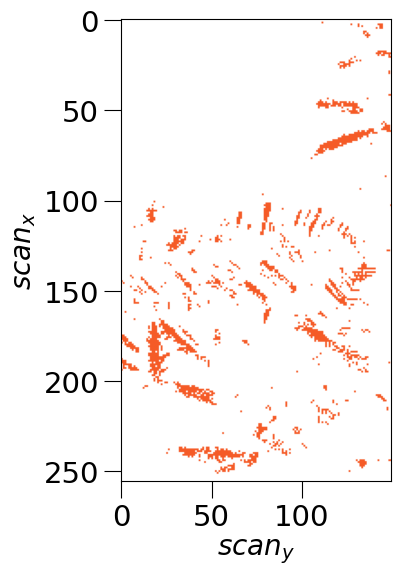

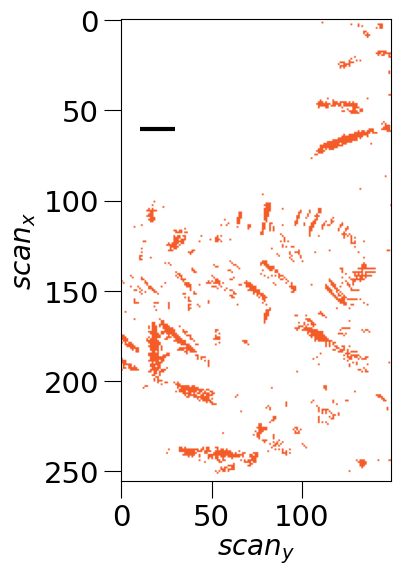

In [12]:
correlation_threshold = 0.98
high_corr_domain_indicating_mask = (zone_axis_local_correlation_value_map_transformer > correlation_threshold)
high_corr_domain_indicating_mask_int = high_corr_domain_indicating_mask.astype(np.int64)


# Define two colors: one for 0, one for 1
discrete_two_color_cmap = ListedColormap(["#ffffff", "#F55B27"])  # 0 → white, 1 → blue

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(high_corr_domain_indicating_mask, cmap=discrete_two_color_cmap)


# cbar = fig.colorbar(im, ax=ax, label='correlation value')
# ax.set_title('highly correlated domain', fontsize=12, pad = 15)
# cbar.ax.tick_params(labelsize=20,length=8, width=0.8)  # Set tick label font size
ax.set_xlabel(r"$scan_{y}$", fontsize = 20)
ax.set_ylabel(r"$scan_{x}$", fontsize = 20)
ax.set_yticks([0, 50, 100, 150, 200, 250])
ax.set_xticks([0, 50, 100])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=21)
fig.savefig(fig05_panel_a_c_path + trained_model_indicator_index + '_highly_correlated_domain_based_on_symmetryReducedZ_from_transformerPrediction.pdf', bbox_inches='tight', dpi=300)
plt.show()

scan_space_pixel_spacing_nm = 20.2 #[nm]
bar_length_nm = 400 #[nm]
bar_length_pixel = bar_length_nm / scan_space_pixel_spacing_nm

scale_bar_y = 60
scale_bar_x_start = 10
scale_bar_x_end = scale_bar_x_start + bar_length_pixel

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(high_corr_domain_indicating_mask, cmap=discrete_two_color_cmap)
ax.plot([scale_bar_x_start, scale_bar_x_end],[scale_bar_y, scale_bar_y], color = "black", lw=3, solid_capstyle="butt")
ax.set_xlabel(r"$scan_{y}$", fontsize = 20)
ax.set_ylabel(r"$scan_{x}$", fontsize = 20)
ax.set_yticks([0, 50, 100, 150, 200, 250])
ax.set_xticks([0, 50, 100])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=21)
fig.savefig(fig05_panel_a_c_path + trained_model_indicator_index + '_highly_correlated_domain_based_on_symmetryReducedZ_from_transformerPrediction_with_scale_bar.pdf', bbox_inches='tight', dpi=300)
plt.show()



#### From py4DSTEM orientation map get zone-axis for each scan position

In [13]:
with open(processed_data_saving_path + 'orientation_map_from_py4DSTEM_cortThForTemp_%d.pkl'%(correlationThresholdTemplateMatch), 'rb') as f:
    py4DSTEM_orientation_map = pickle.load(f)

zone_axis_map_py4DSTEM = np.zeros((scan_x_dim,scan_y_dim,3))
symmReduced_x_axis_map_py4DSTEM = np.zeros((scan_x_dim,scan_y_dim,3))

py4DSTEM_mask_for_pixel_where_orientation_is_detected = np.zeros((scan_x_dim,scan_y_dim), dtype = np.int64)

for key, value in table_BPs_scanIndex.items():
    

    i, j = value['scanIndices'][0], value['scanIndices'][1]

    if np.sum(np.abs(py4DSTEM_orientation_map.family[i,j][0])) > 1e-6:
        py4DSTEM_mask_for_pixel_where_orientation_is_detected[i,j] = int(1)

    
    
    zone_axis_map_py4DSTEM[i,j] = py4DSTEM_orientation_map.family[i,j][0][:,2]
    symmReduced_x_axis_map_py4DSTEM[i,j] = py4DSTEM_orientation_map.family[i,j][0][:,0]

py4DSTEM_zone_axis_correlation_map = zone_axis_local_correlation_map(zone_axis_map_py4DSTEM, mask_showing_where_crystal_is_located)
py4DSTEM_symmReduced_x_axis_correlation_map = zone_axis_local_correlation_map(symmReduced_x_axis_map_py4DSTEM, mask_showing_where_crystal_is_located)


### Find scan position where both methods declare that crystal is located

In [14]:
mask_for_correlations = np.multiply(py4DSTEM_mask_for_pixel_where_orientation_is_detected, high_corr_domain_indicating_mask)

### Measure two-point correlation

In [15]:
corr_map_transformer = zone_axis_autocorrelation_map_masked(zone_axis_map_transformer, mask_for_correlations)
corr_map_py4DSTEM = zone_axis_autocorrelation_map_masked(zone_axis_map_py4DSTEM, mask_for_correlations)
cross_corr_py4DSTEM_transformer = zone_axis_cross_correlation_map_masked(zone_axis_map_transformer, zone_axis_map_py4DSTEM, mask_for_correlations)
corr_map_py4DSTEM_entire = zone_axis_autocorrelation_map_masked(zone_axis_map_py4DSTEM, py4DSTEM_mask_for_pixel_where_orientation_is_detected)

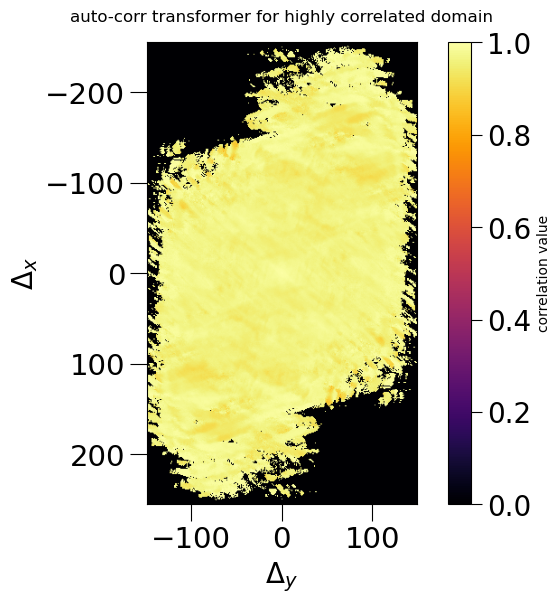

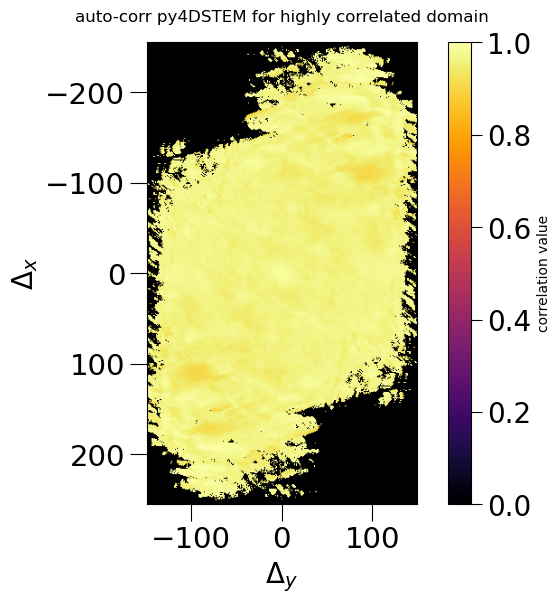

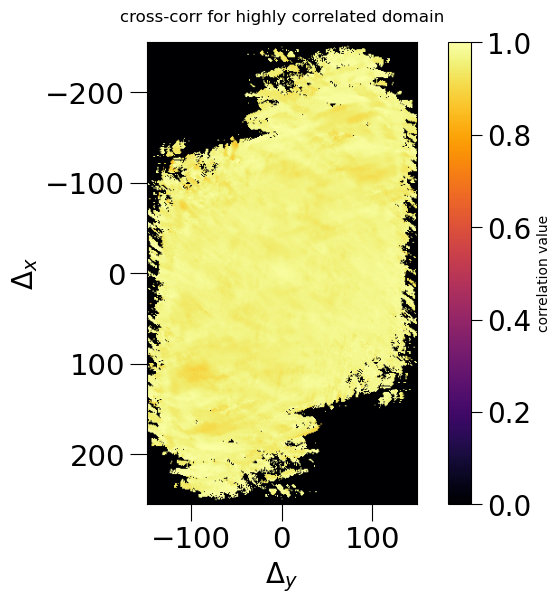

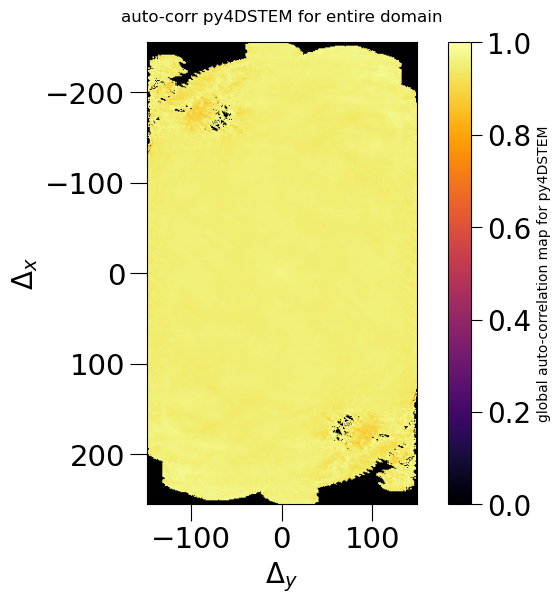

In [16]:



# --- Figure 1: Transformer auto-correlation ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_map_transformer, cmap='inferno', vmin = 0.0, vmax = 1.0, extent = [-(scan_y_dim - 1),(scan_y_dim - 1),(scan_x_dim - 1),-(scan_x_dim - 1)])
cbar = fig.colorbar(im, ax=ax, label='correlation value')
ax.set_title('auto-corr transformer for highly correlated domain', fontsize=12, pad = 15)
cbar.ax.tick_params(labelsize=20,length=8, width=0.8)  # Set tick label font size
ax.set_xlabel(r"$\Delta_y$", fontsize = 20)
ax.set_ylabel(r"$\Delta_x$", fontsize = 20)
ax.set_xticks([-100, 0, 100])
ax.set_yticks([-200, -100, 0, 100, 200])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=21)
# fig.savefig('auto_corr_symmReducedZ_transformer_prediction_highly_correlated_domain.pdf', bbox_inches='tight', dpi=300)
plt.show()

# --- Figure 2: Py4DSTEM auto-correlation (predicted region) ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_map_py4DSTEM, cmap='inferno', vmin = 0.0, vmax = 1.0, extent = [-(scan_y_dim - 1),(scan_y_dim - 1),(scan_x_dim - 1),-(scan_x_dim - 1)])
cbar = fig.colorbar(im, ax=ax, label='correlation value')
cbar.ax.tick_params(labelsize=20,length=8, width=0.8)  # Set tick label font size
ax.set_title('auto-corr py4DSTEM for highly correlated domain', fontsize=12, pad = 15)
ax.set_xlabel(r"$\Delta_y$", fontsize = 20)
ax.set_ylabel(r"$\Delta_x$", fontsize = 20)
ax.set_xticks([-100, 0, 100])
ax.set_yticks([-200, -100, 0, 100, 200])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=21)
# fig.savefig('auto_corr_symmReducedZ_py4DSTEM_prediction_highly_correlated_domain.pdf', bbox_inches='tight', dpi=300)
plt.show()

# --- Figure 3: Cross-correlation ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cross_corr_py4DSTEM_transformer, cmap='inferno', vmin = 0.0, vmax = 1.0, extent = [-(scan_y_dim - 1),(scan_y_dim - 1),(scan_x_dim - 1),-(scan_x_dim - 1)])
cbar = fig.colorbar(im, ax=ax, label='correlation value')
cbar.ax.tick_params(labelsize=20,length=8, width=0.8)  # Set tick label font size
ax.set_title('cross-corr for highly correlated domain', fontsize=12, pad = 15)
ax.set_xlabel(r"$\Delta_y$", fontsize = 20)
ax.set_ylabel(r"$\Delta_x$", fontsize = 20)
ax.set_xticks([-100, 0, 100])
ax.set_yticks([-200, -100, 0, 100, 200])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=21)
# fig.savefig('cross_corr_symmReducedZ_both_predictions_highly_correlated_domain.pdf', bbox_inches='tight', dpi=300)
plt.show()

# --- Figure 4: Py4DSTEM entire region auto-correlation ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_map_py4DSTEM_entire, cmap='inferno', vmin = 0.0, vmax = 1.0, extent = [-(scan_y_dim - 1),(scan_y_dim - 1),(scan_x_dim - 1),-(scan_x_dim - 1)])
cbar = fig.colorbar(im, ax=ax, label='global auto-correlation map for py4DSTEM')
cbar.ax.tick_params(labelsize=20,length=8, width=0.8)  # Set tick label font size
ax.set_title('auto-corr py4DSTEM for entire domain', fontsize=12, pad = 15)
ax.set_xlabel(r"$\Delta_y$", fontsize = 20)
ax.set_ylabel(r"$\Delta_x$", fontsize = 20)
ax.set_xticks([-100, 0, 100])
ax.set_yticks([-200, -100, 0, 100, 200])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=21)
# fig.savefig('auto_corr_symmReducedZ_py4DSTEM_prediction_highly_correlated_domain.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [17]:

window = 35
center_0 = scan_x_dim - 1
center_1 = scan_y_dim - 1
corr_map_transformer_windowed = corr_map_transformer[int(center_0 - window):int(center_0 + window + 1),int(center_1 - window):int(center_1 + window + 1)]
corr_map_py4DSTEM_windowed = corr_map_py4DSTEM[int(center_0 - window):int(center_0 + window + 1),int(center_1 - window):int(center_1 + window + 1)]
cross_corr_py4DSTEM_transformer_windowed = cross_corr_py4DSTEM_transformer[int(center_0 - window):int(center_0 + window + 1),int(center_1 - window):int(center_1 + window + 1)]

corr_map_py4DSTEM_entire_windowed = corr_map_py4DSTEM_entire[int(center_0 - window):int(center_0 + window + 1),int(center_1 - window):int(center_1 + window + 1)]

vmin_value_for_window = np.min(np.array([np.min(corr_map_transformer_windowed), np.min(corr_map_py4DSTEM_windowed), np.min(cross_corr_py4DSTEM_transformer_windowed), np.min(corr_map_py4DSTEM_entire_windowed)]))
vmin_value_for_window


np.float64(0.9336129940181831)

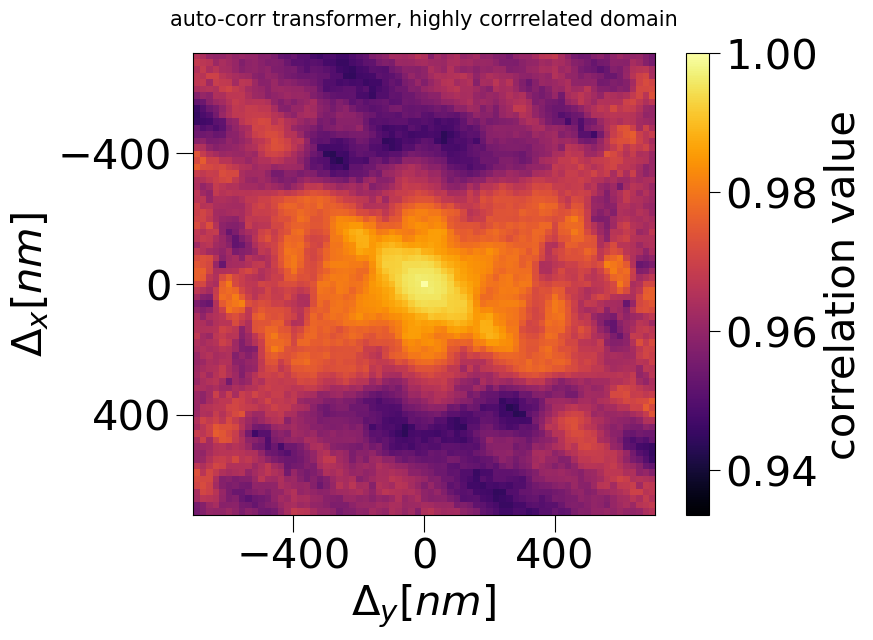

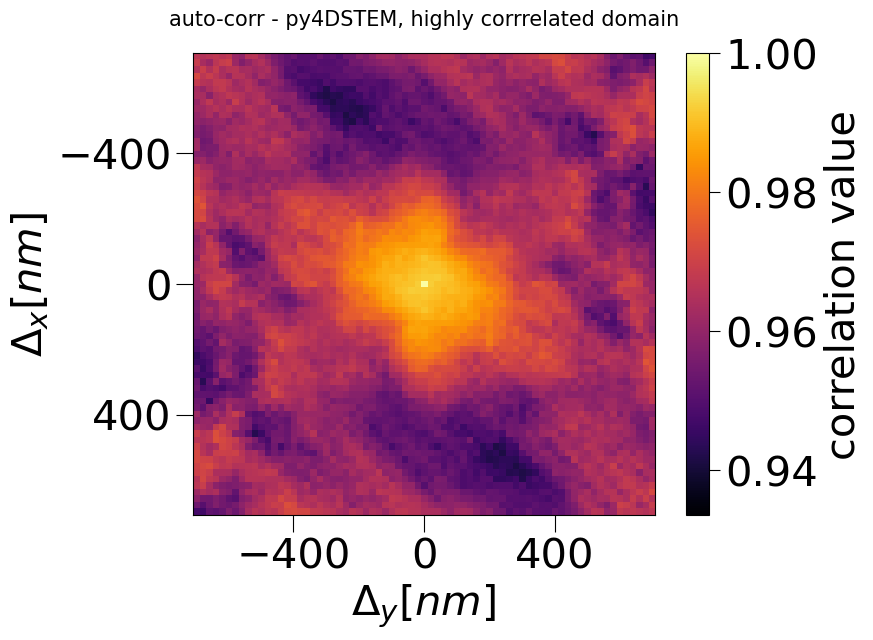

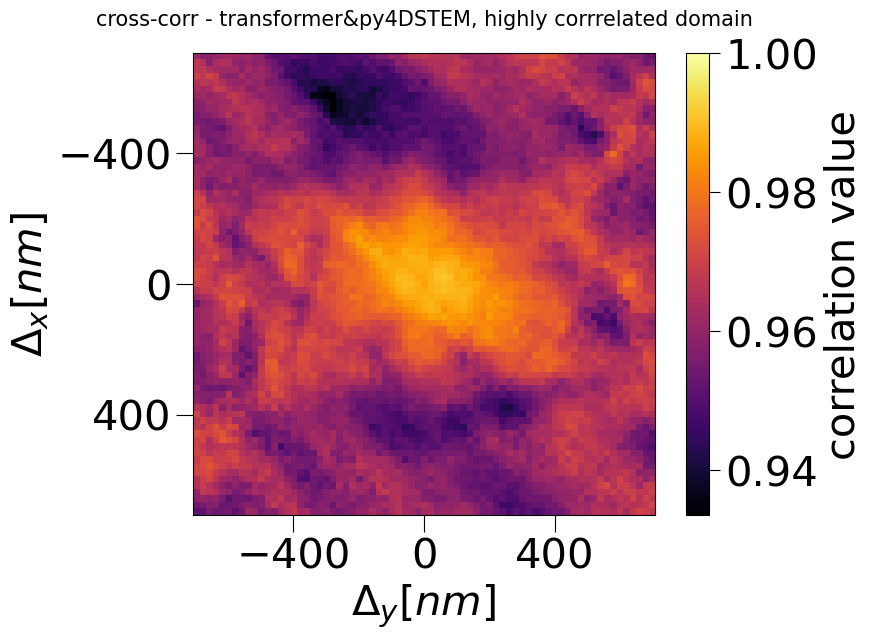

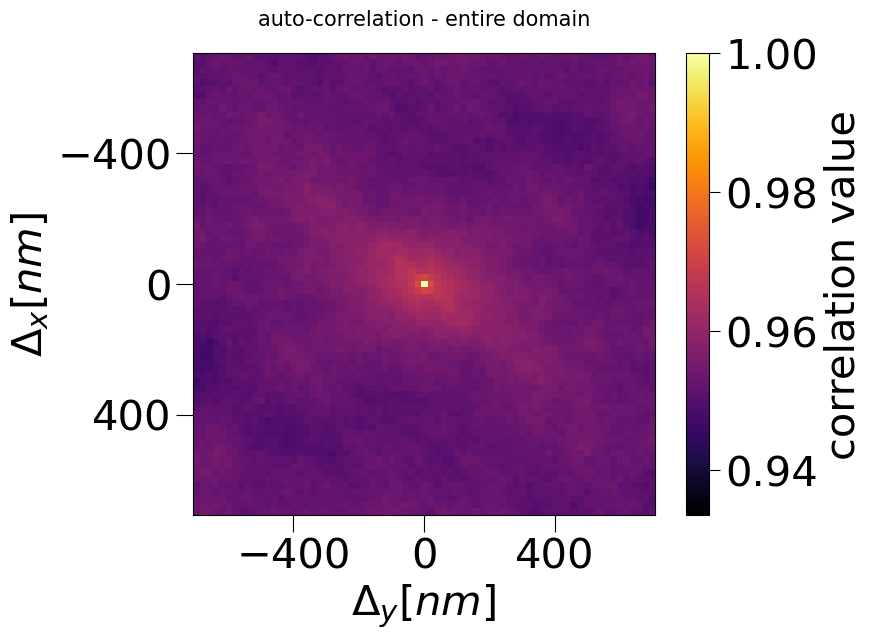

In [20]:
# import matplotlib.pyplot as plt

# scan_space_pixel_spacing_nm = 20.2 #[nm]

# Transformer windowed
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_map_transformer_windowed, cmap='inferno', vmin=vmin_value_for_window, vmax=1.0, extent = [-window*scan_space_pixel_spacing_nm,window*scan_space_pixel_spacing_nm,window*scan_space_pixel_spacing_nm,-window*scan_space_pixel_spacing_nm])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('correlation value', fontsize=30)
cbar.ax.tick_params(labelsize=30,length=8, width=0.8)  # Set tick label font size
ax.set_xlabel(r"$\Delta_y [nm]$", fontsize = 30)
ax.set_ylabel(r"$\Delta_x [nm]$", fontsize = 30)
ax.set_xticks([-400, 0, 400])
ax.set_yticks([-400, 0, 400])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=30)
ax.set_title('auto-corr transformer, highly corrrelated domain', fontsize=15, pad=20)
fig.savefig(fig05_panel_d_f_path + trained_model_indicator_index + '_center_patch_auto_corr_symmReducedZ_transformer_prediction_highly_correlated_domain_nm.pdf', bbox_inches='tight', dpi=300)
plt.show()

# py4DSTEM windowed
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_map_py4DSTEM_windowed, cmap='inferno', vmin=vmin_value_for_window, vmax=1.0, extent = [-window*scan_space_pixel_spacing_nm,window*scan_space_pixel_spacing_nm,window*scan_space_pixel_spacing_nm,-window*scan_space_pixel_spacing_nm])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('correlation value', fontsize=30)
cbar.ax.tick_params(labelsize=30,length=8, width=0.8)  # Set tick label font size
ax.set_xlabel(r"$\Delta_y [nm]$", fontsize = 30)
ax.set_ylabel(r"$\Delta_x [nm]$", fontsize = 30)
ax.set_xticks([-400, 0, 400])
ax.set_yticks([-400, 0, 400])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=30)
ax.set_title('auto-corr - py4DSTEM, highly corrrelated domain', fontsize=15, pad=20)
fig.savefig(fig05_panel_d_f_path + trained_model_indicator_index + '_center_patch_auto_corr_symmReducedZ_py4DSTEM_prediction_highly_correlated_domain_nm.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Cross-correlation transformer
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cross_corr_py4DSTEM_transformer_windowed, cmap='inferno', vmin=vmin_value_for_window, vmax=1.0, extent = [-window*scan_space_pixel_spacing_nm,window*scan_space_pixel_spacing_nm,window*scan_space_pixel_spacing_nm,-window*scan_space_pixel_spacing_nm])
cbar = fig.colorbar(im, ax=ax)

cbar.set_label('correlation value', fontsize=30)
cbar.ax.tick_params(labelsize=30,length=8, width=0.8)  # Set tick label font size
ax.set_xlabel(r"$\Delta_y [nm]$", fontsize = 30)
ax.set_ylabel(r"$\Delta_x [nm]$", fontsize = 30)
ax.set_xticks([-400, 0, 400])
ax.set_yticks([-400, 0, 400])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=30)
ax.set_title('cross-corr - transformer&py4DSTEM, highly corrrelated domain', fontsize=15, pad=20)
fig.savefig(fig05_panel_d_f_path + trained_model_indicator_index + '_center_patch_cross_corr_symmReducedZ_highly_correlated_domain_nm.pdf', bbox_inches='tight', dpi=300)
plt.show()

# py4DSTEM entire
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_map_py4DSTEM_entire_windowed, cmap='inferno', vmin=vmin_value_for_window, vmax=1.0, extent = [-window*scan_space_pixel_spacing_nm,window*scan_space_pixel_spacing_nm,window*scan_space_pixel_spacing_nm,-window*scan_space_pixel_spacing_nm])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('correlation value', fontsize=30)
cbar.ax.tick_params(labelsize=30,length=8, width=0.8)  # Set tick label font size
ax.set_xlabel(r"$\Delta_y [nm]$", fontsize = 30)
ax.set_ylabel(r"$\Delta_x [nm]$", fontsize = 30)
ax.set_xticks([-400, 0, 400])
ax.set_yticks([-400, 0, 400])
ax.tick_params(axis='both', direction='out', length=12, width=0.8, color='k', labelsize=30)
ax.set_title('auto-correlation - entire domain', fontsize=15, pad=20)
fig.savefig(fig05_panel_d_f_path + trained_model_indicator_index + '_center_patch_auto_corr_symmReducedZ_py4DSTEM_prediction_entire_domain_nm.pdf', bbox_inches='tight', dpi=300)
plt.show()


### Perform radial average

In [21]:
corr_map_transformer_windowed_radial_centers, corr_map_transformer_windowed_radial_profile = radial_average_corrMap(corr_map_transformer_windowed)
corr_map_py4DSTEM_windowed_radial_centers, corr_map_py4DSTEM_windowed_radial_profile = radial_average_corrMap(corr_map_py4DSTEM_windowed)

cross_corr_map_windowed_radial_centers, cross_corr_map_windowed_radial_profile = radial_average_corrMap(cross_corr_py4DSTEM_transformer_windowed)
corr_map_py4DSTEM_entire_windowed_radial_centers, corr_map_py4DSTEM_entire_windowed_radial_profile = radial_average_corrMap(corr_map_py4DSTEM_entire_windowed)



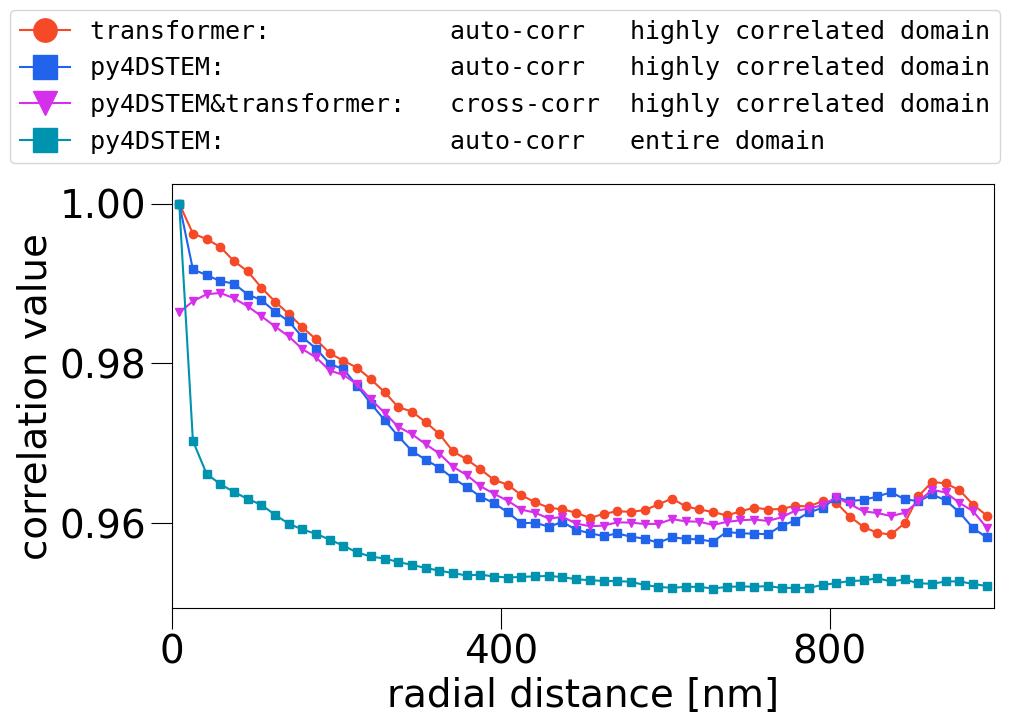

In [24]:
import matplotlib.pyplot as plt

scan_space_pixel_spacing_nm = 20.2 #[nm]

fig, ax = plt.subplots(figsize=(10.6, 5.5))

methods = ["transformer: ", "py4DSTEM: ", "py4DSTEM&transformer: ", "py4DSTEM: "]
types   = ["auto-corr", "auto-corr", "cross-corr", "auto-corr"]
domain   = ["highly correlated domain", "highly correlated domain",
           "highly correlated domain", "entire domain"]


# Set fixed widths
method_width = 23  # adjust to fit longest method
type_width   = 11  # adjust to fit longest type
domain_width = 24
# Build formatted labels
labels = [f"{m:<{method_width}} {t:<{type_width}} {d:<{domain_width}}" 
          for m, t, d in zip(methods, types, domain)]


ax.plot(scan_space_pixel_spacing_nm * corr_map_transformer_windowed_radial_centers, 
        corr_map_transformer_windowed_radial_profile, 
        marker='o', label=labels[0], color = "#F54927")

ax.plot(scan_space_pixel_spacing_nm * corr_map_py4DSTEM_windowed_radial_centers, 
        corr_map_py4DSTEM_windowed_radial_profile, 
        marker='s', label=labels[1], color = "#2164EB")

ax.plot(scan_space_pixel_spacing_nm * cross_corr_map_windowed_radial_centers, 
        cross_corr_map_windowed_radial_profile, 
        marker='v', label=labels[2], color = "#D62FEB")

ax.plot(scan_space_pixel_spacing_nm * corr_map_py4DSTEM_entire_windowed_radial_centers, 
        corr_map_py4DSTEM_entire_windowed_radial_profile, 
        marker='s', label=labels[3], color = "#0093AF")

ax.set_xlabel('radial distance [nm]', fontsize=28)
ax.set_ylabel('correlation value', fontsize=28)
# ax.set_title('1D Radial Profile', fontsize=24)
ax.set_xlim([-0.1,1000])
# Customize ticks
ax.tick_params(axis='both',       # x and y axis
               which='major',    # major ticks
               length=15,        # tick length in points
               width=0.8,          # tick width
               labelsize=28)     # font size of tick labels
# ax.grid(True)
# ax.legend(fontsize=18)  # Display legend
ax.set_xticks([0,400, 800])
ax.set_yticks([0.96,0.98,1.00])
ax.legend(fontsize=18, prop={'family': 'monospace', 'size': 18},
         loc='lower center',           # location reference point
          bbox_to_anchor=(0.405, 1.02),
         markerscale = 2.8,)


fig.savefig(fig05_panel_d_f_path + trained_model_indicator_index +'_compare_radial_averaged_correlation_values_nm.pdf', bbox_inches='tight', dpi=300)

plt.show()
